FOOD DELIVERY BUSINESS PERFORMANCE - VISUALIZATION PORTFOLIO

Dataset Shape: (360, 16)

Columns:
['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

First 5 Records:
  Order_Batch_ID       Date    Month       Day        City       Cuisine  \
0         FD0001 2025-03-22    March  Saturday   Hyderabad  North Indian   
1         FD0002 2025-04-15    April   Tuesday  Chandigarh       Chinese   
2         FD0003 2025-01-26  January    Sunday      Mumbai       Healthy   
3         FD0004 2025-06-20     June    Friday        Pune       Chinese   
4         FD0005 2025-08-07   August  Thursday   Bengaluru     Fast Food   

      Order_Channel Weather  Orders  Average_Order_Value   Revenue  \
0               App     Hot     156               421.03  67374.27   
1               App   Rainy     129               37

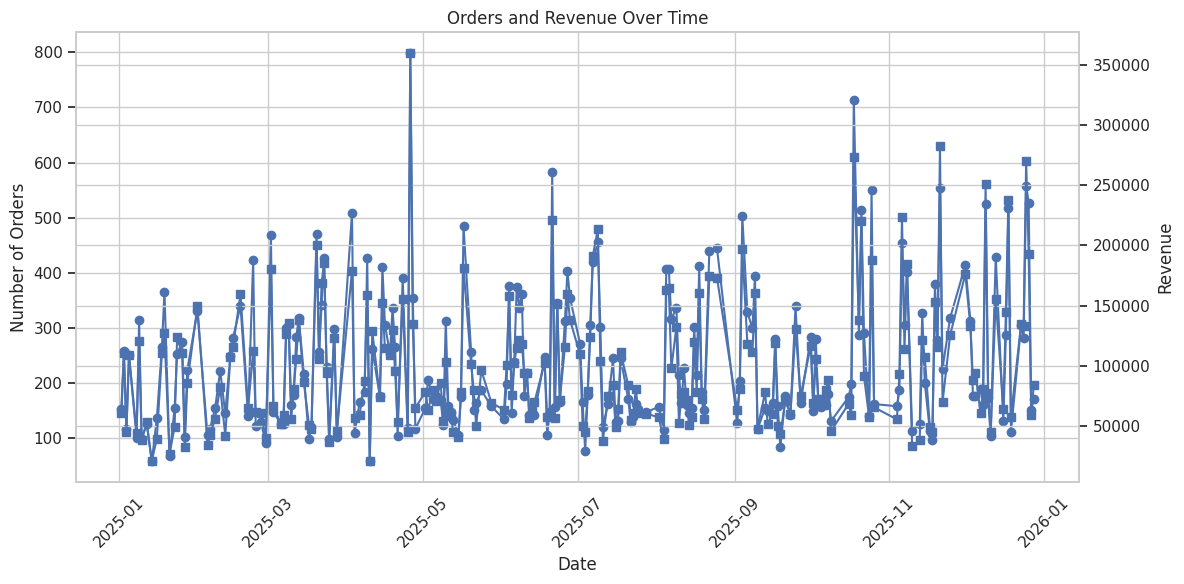


INTERPRETATION - LINE PLOT:
The line chart shows how order volume and revenue change over time.
Peaks in orders generally correspond to periods of higher revenue.
Comparing the two lines helps identify strong and weak business
periods and whether revenue changes are primarily associated with
changes in order volume.



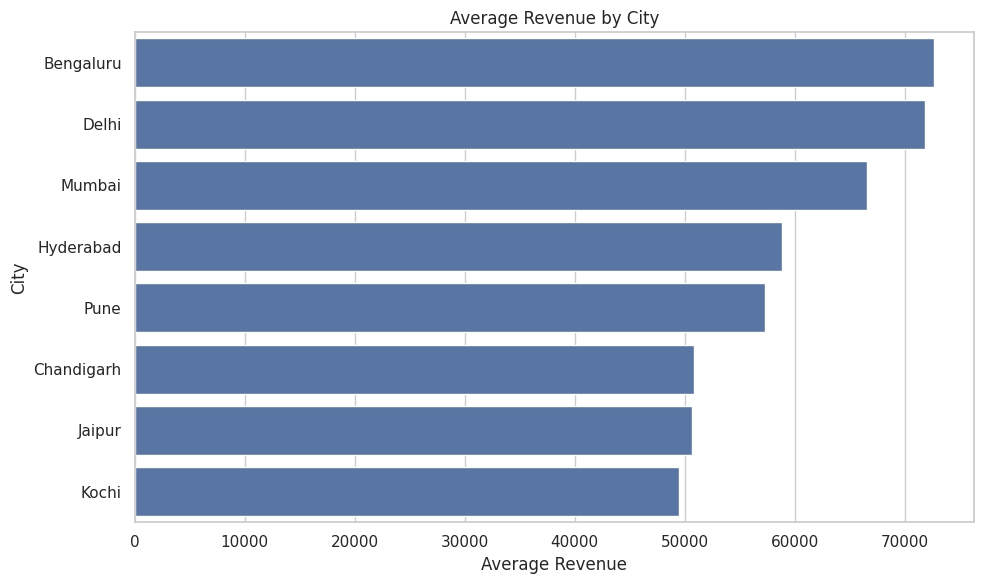


INTERPRETATION - CITY BAR CHART:
The chart compares the average revenue generated by each city.
Bengaluru records the highest average revenue, followed closely
by Delhi and Mumbai, while Kochi and Jaipur are among the lower
performing cities.



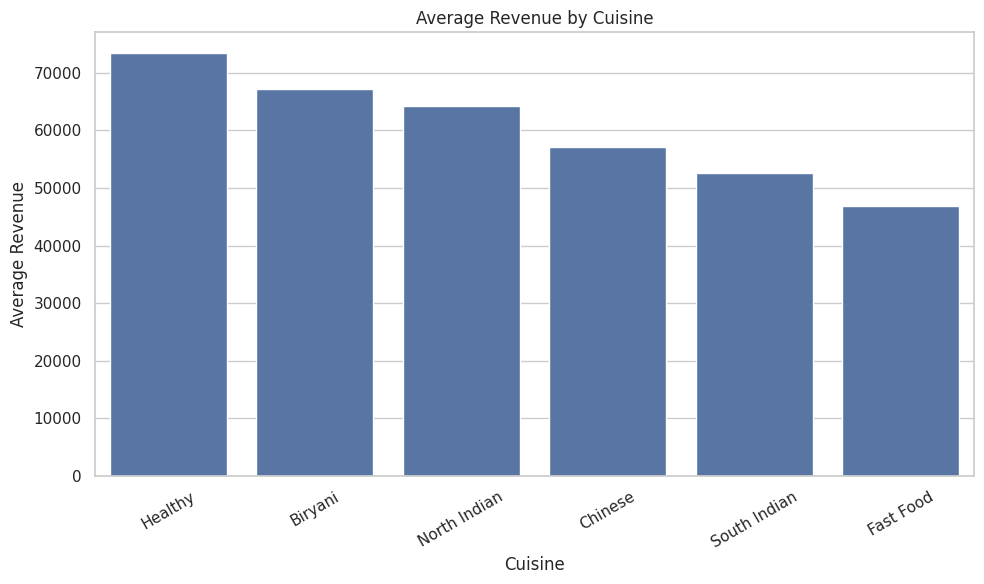


INTERPRETATION - CUISINE BAR CHART:
Healthy cuisine has the highest average revenue in the dataset,
followed by Biryani and North Indian cuisine. Fast Food has the
lowest average revenue despite having a relatively high order
volume, suggesting that average order value may differ considerably
between cuisines.



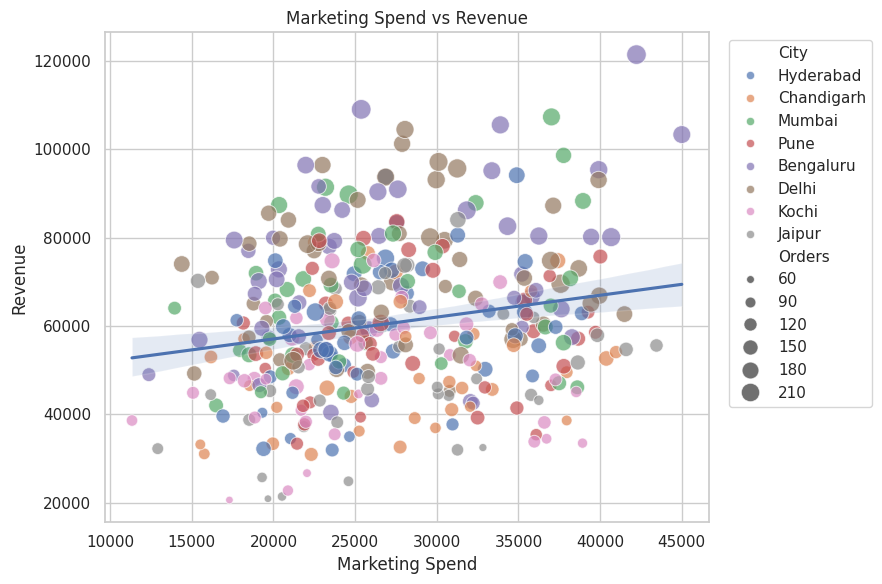


INTERPRETATION - MARKETING VS REVENUE:
Marketing spend and revenue have a correlation of
0.20. This indicates a positive but
relatively moderate relationship. Higher marketing expenditure
is associated with higher revenue in some observations, but
marketing spend alone does not explain all revenue variation.



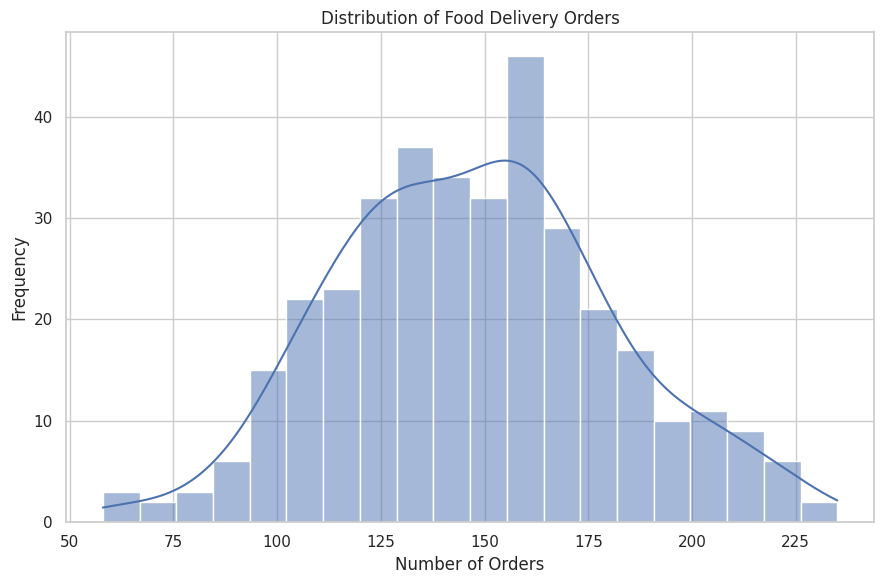


INTERPRETATION - HISTOGRAM:
The histogram shows the distribution of order volumes across
the dataset. It helps identify the typical order range and whether
there are unusually high or low order-volume observations.



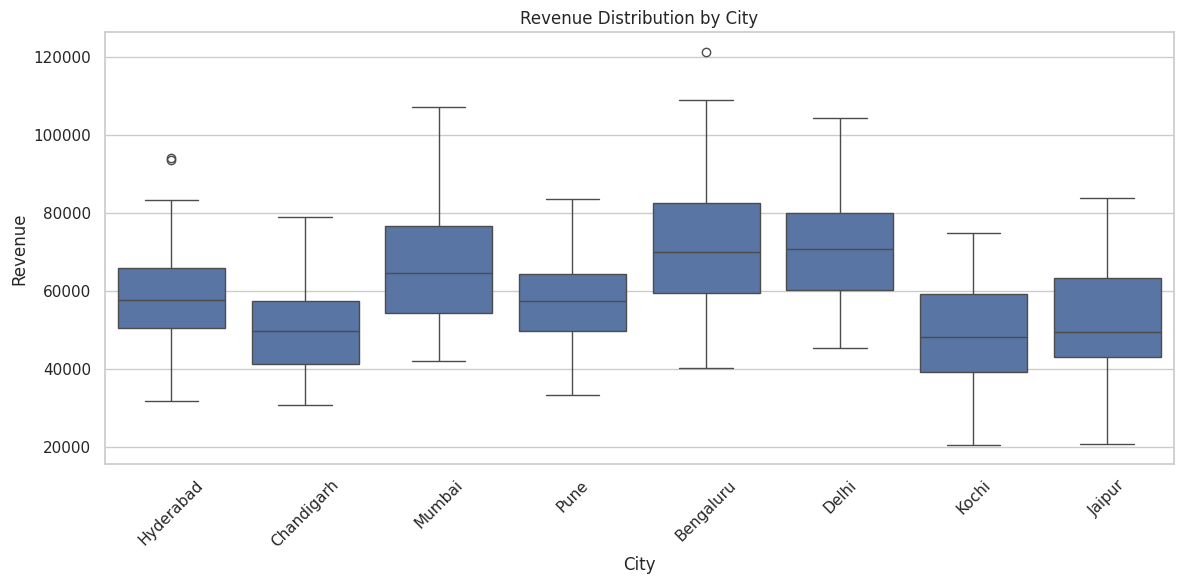


INTERPRETATION - BOX PLOT:
The box plot compares revenue distributions rather than just
average revenue. It shows the median, spread, and potential
extreme observations for each city, making it possible to identify
cities with greater revenue variability.



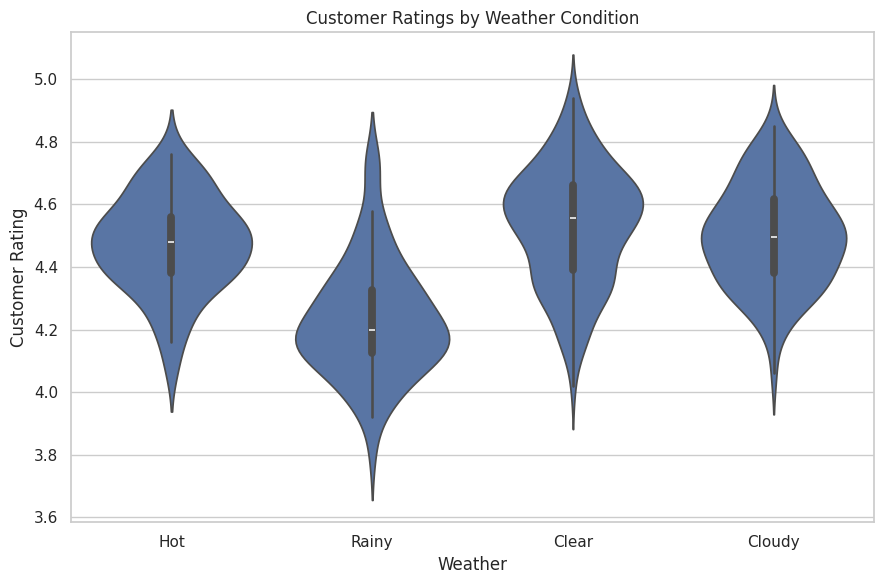


INTERPRETATION - VIOLIN PLOT:
Customer ratings vary noticeably with weather conditions.
Rainy weather has the lowest average rating, while Clear weather
has the highest average rating. The wider portions of each violin
show where ratings are most concentrated.



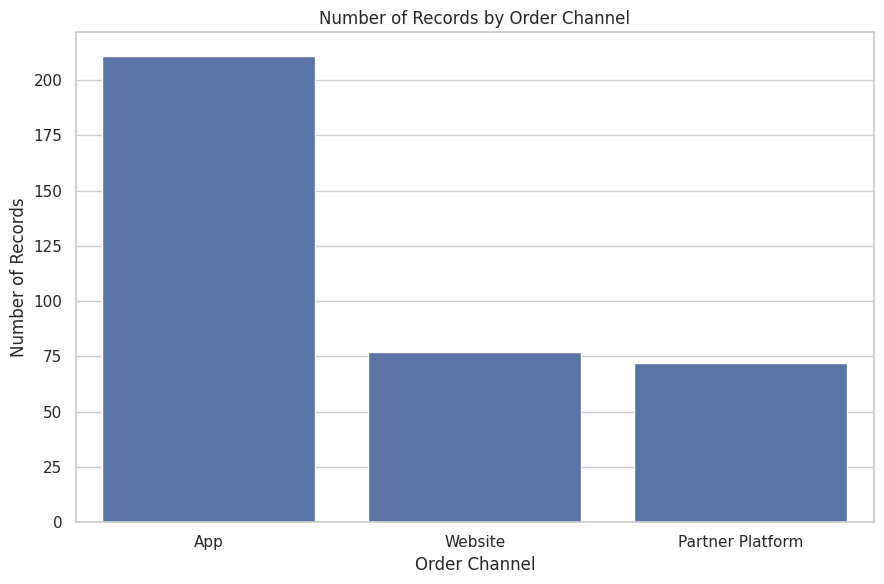


INTERPRETATION - COUNT PLOT:
The count plot shows how the dataset's observations are distributed
across App, Website, and Partner Platform channels. This helps
identify which channels have the greatest representation in the
business data.



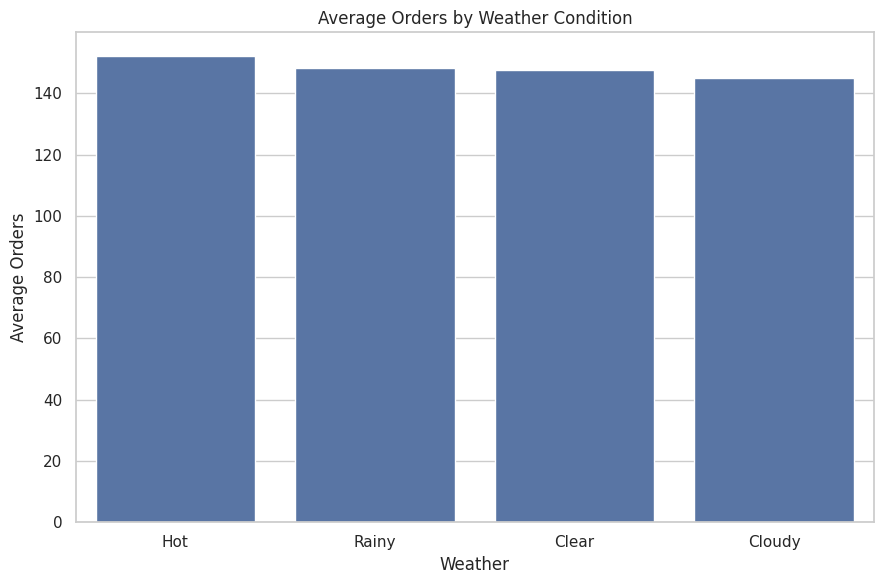


INTERPRETATION - WEATHER BAR CHART:
Hot weather has the highest average number of orders, while Cloudy
weather has the lowest. However, the difference in order volume
between weather conditions is relatively moderate, suggesting that
weather does not have as large an effect on order volume as it does
on delivery experience.



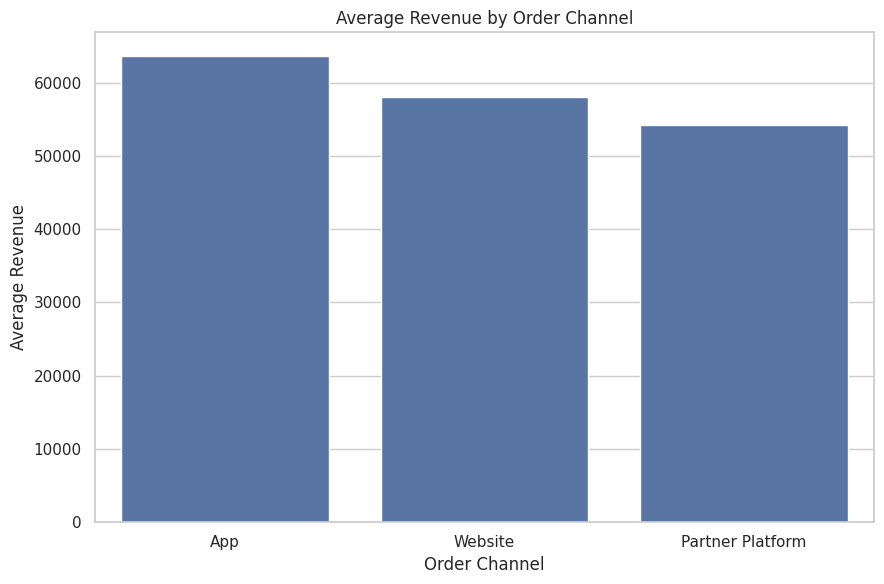


INTERPRETATION - ORDER CHANNEL:
The App has the highest average revenue among the three order
channels. Website and Partner Platform generate lower average
revenue per observation, indicating that the App is an important
sales channel for the business.



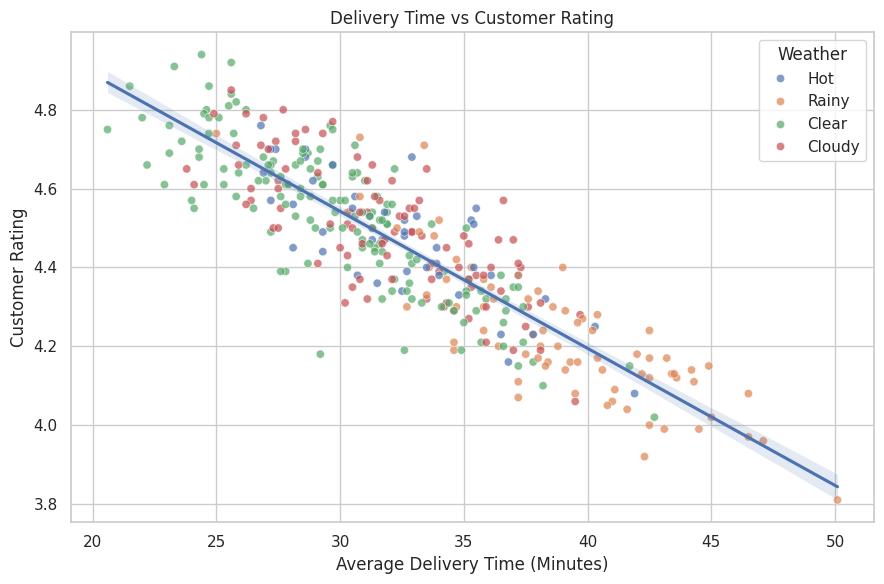


INTERPRETATION - DELIVERY TIME VS RATING:
Delivery time and customer rating have a correlation of
-0.88. This is a strong negative relationship,
meaning that longer delivery times are generally associated with
lower customer ratings. Rainy weather may contribute to this effect
because rainy periods also show longer average delivery times.



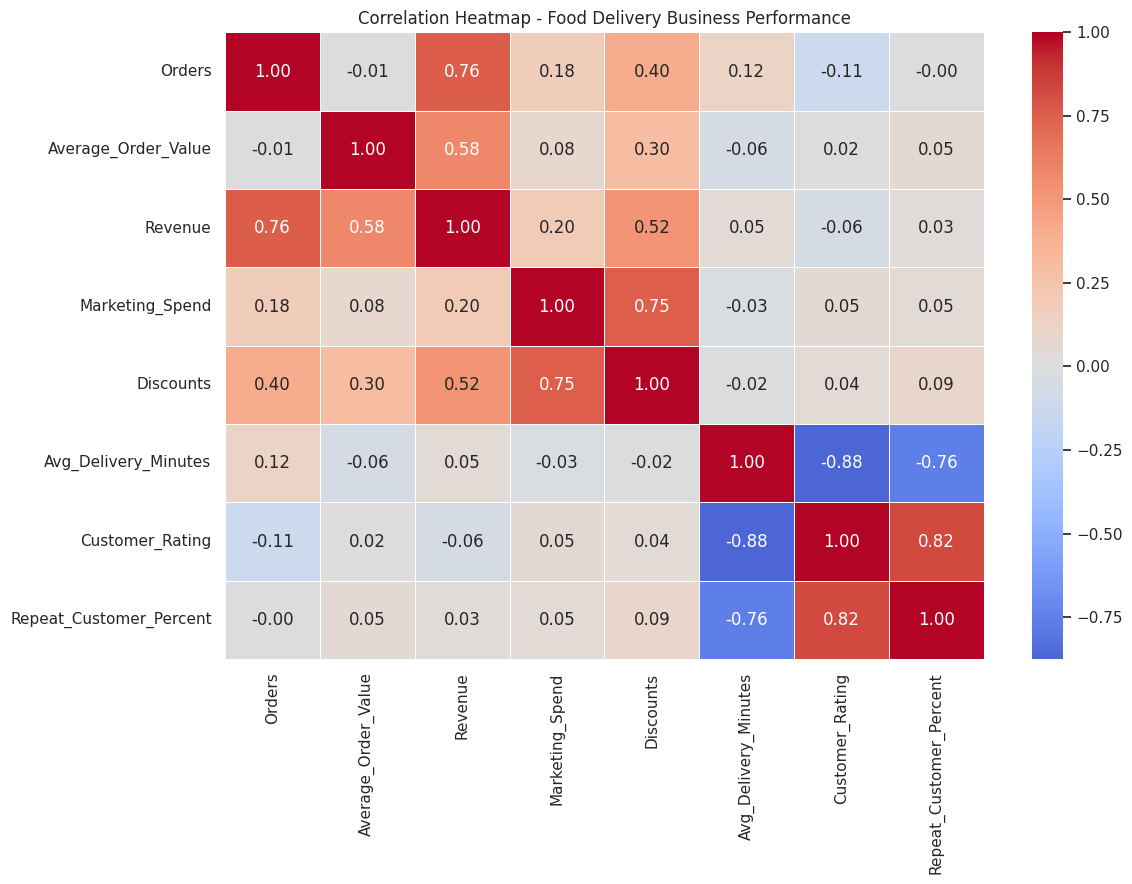


INTERPRETATION - CORRELATION HEATMAP:
The heatmap provides an overall view of relationships between
the numerical business variables. In particular, it helps identify
whether revenue is associated with order volume, average order
value, marketing spending, discounts, delivery time, ratings, or
repeat customers.


BUSINESS PERFORMANCE COMPARISON

Average Performance by City:
            Orders   Revenue  Customer_Rating
City                                         
Bengaluru   177.25  72678.47             4.43
Chandigarh  125.05  50860.41             4.49
Delhi       175.25  71852.53             4.41
Hyderabad   148.75  58841.31             4.47
Jaipur      117.40  50696.35             4.48
Kochi       120.80  49461.84             4.46
Mumbai      161.78  66595.21             4.42
Pune        138.38  57292.23             4.47

Average Performance by Cuisine:
              Orders   Revenue  Average_Order_Value
Cuisine                                            
Biryani       145.38  671

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

FILE_PATH = "Day14_Food_Delivery_Visualization_Dataset.csv"

df = pd.read_csv(FILE_PATH)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Set a consistent visualization style
sns.set_theme(style="whitegrid")

print("=" * 75)
print("FOOD DELIVERY BUSINESS PERFORMANCE - VISUALIZATION PORTFOLIO")
print("=" * 75)

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
print(df.head())


# ------------------------------------------------------------
# 2. BASIC DATA CHECK
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DATA QUALITY CHECK")
print("=" * 75)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())


# ============================================================
# VISUALIZATION 1 - LINE PLOT
# Orders and Revenue Over Time
# ============================================================

daily_performance = (
    df.groupby("Date")
      .agg({
          "Orders": "sum",
          "Revenue": "sum"
      })
      .reset_index()
      .sort_values("Date")
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    daily_performance["Date"],
    daily_performance["Orders"],
    marker="o",
    label="Orders"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Orders")
ax1.set_title("Orders and Revenue Over Time")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    daily_performance["Date"],
    daily_performance["Revenue"],
    marker="s",
    label="Revenue"
)

ax2.set_ylabel("Revenue")

fig.tight_layout()
plt.show()

print("""
INTERPRETATION - LINE PLOT:
The line chart shows how order volume and revenue change over time.
Peaks in orders generally correspond to periods of higher revenue.
Comparing the two lines helps identify strong and weak business
periods and whether revenue changes are primarily associated with
changes in order volume.
""")


# ============================================================
# VISUALIZATION 2 - BAR CHART
# Average Revenue by City
# ============================================================

city_revenue = (
    df.groupby("City")["Revenue"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_revenue,
    x="Revenue",
    y="City"
)

plt.title("Average Revenue by City")
plt.xlabel("Average Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.show()

print("""
INTERPRETATION - CITY BAR CHART:
The chart compares the average revenue generated by each city.
Bengaluru records the highest average revenue, followed closely
by Delhi and Mumbai, while Kochi and Jaipur are among the lower
performing cities.
""")


# ============================================================
# VISUALIZATION 3 - BAR CHART
# Average Revenue by Cuisine
# ============================================================

cuisine_revenue = (
    df.groupby("Cuisine")["Revenue"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cuisine_revenue,
    x="Cuisine",
    y="Revenue"
)

plt.title("Average Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Revenue")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print("""
INTERPRETATION - CUISINE BAR CHART:
Healthy cuisine has the highest average revenue in the dataset,
followed by Biryani and North Indian cuisine. Fast Food has the
lowest average revenue despite having a relatively high order
volume, suggesting that average order value may differ considerably
between cuisines.
""")


# ============================================================
# VISUALIZATION 4 - SCATTER PLOT
# Marketing Spend vs Revenue
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    hue="City",
    size="Orders",
    sizes=(30, 200),
    alpha=0.7
)

sns.regplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    scatter=False
)

plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

marketing_revenue_corr = df[
    ["Marketing_Spend", "Revenue"]
].corr().iloc[0, 1]

print(f"""
INTERPRETATION - MARKETING VS REVENUE:
Marketing spend and revenue have a correlation of
{marketing_revenue_corr:.2f}. This indicates a positive but
relatively moderate relationship. Higher marketing expenditure
is associated with higher revenue in some observations, but
marketing spend alone does not explain all revenue variation.
""")


# ============================================================
# VISUALIZATION 5 - HISTOGRAM
# Distribution of Orders
# ============================================================

plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="Orders",
    bins=20,
    kde=True
)

plt.title("Distribution of Food Delivery Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("""
INTERPRETATION - HISTOGRAM:
The histogram shows the distribution of order volumes across
the dataset. It helps identify the typical order range and whether
there are unusually high or low order-volume observations.
""")


# ============================================================
# VISUALIZATION 6 - BOX PLOT
# Revenue by City
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Revenue"
)

plt.title("Revenue Distribution by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("""
INTERPRETATION - BOX PLOT:
The box plot compares revenue distributions rather than just
average revenue. It shows the median, spread, and potential
extreme observations for each city, making it possible to identify
cities with greater revenue variability.
""")


# ============================================================
# VISUALIZATION 7 - VIOLIN PLOT
# Customer Ratings by Weather
# ============================================================

plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="Weather",
    y="Customer_Rating"
)

plt.title("Customer Ratings by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Customer Rating")

plt.tight_layout()
plt.show()

print("""
INTERPRETATION - VIOLIN PLOT:
Customer ratings vary noticeably with weather conditions.
Rainy weather has the lowest average rating, while Clear weather
has the highest average rating. The wider portions of each violin
show where ratings are most concentrated.
""")


# ============================================================
# VISUALIZATION 8 - COUNT PLOT
# Orders by Order Channel
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Order_Channel",
    order=df["Order_Channel"].value_counts().index
)

plt.title("Number of Records by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

print("""
INTERPRETATION - COUNT PLOT:
The count plot shows how the dataset's observations are distributed
across App, Website, and Partner Platform channels. This helps
identify which channels have the greatest representation in the
business data.
""")


# ============================================================
# VISUALIZATION 9 - BAR CHART
# Average Orders by Weather
# ============================================================

weather_orders = (
    df.groupby("Weather")["Orders"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=weather_orders,
    x="Weather",
    y="Orders"
)

plt.title("Average Orders by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Orders")

plt.tight_layout()
plt.show()

print("""
INTERPRETATION - WEATHER BAR CHART:
Hot weather has the highest average number of orders, while Cloudy
weather has the lowest. However, the difference in order volume
between weather conditions is relatively moderate, suggesting that
weather does not have as large an effect on order volume as it does
on delivery experience.
""")


# ============================================================
# VISUALIZATION 10 - BAR CHART
# Revenue by Order Channel
# ============================================================

channel_revenue = (
    df.groupby("Order_Channel")["Revenue"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=channel_revenue,
    x="Order_Channel",
    y="Revenue"
)

plt.title("Average Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Revenue")

plt.tight_layout()
plt.show()

print("""
INTERPRETATION - ORDER CHANNEL:
The App has the highest average revenue among the three order
channels. Website and Partner Platform generate lower average
revenue per observation, indicating that the App is an important
sales channel for the business.
""")


# ============================================================
# VISUALIZATION 11 - SCATTER PLOT
# Delivery Time vs Customer Rating
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    hue="Weather",
    alpha=0.7
)

sns.regplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    scatter=False
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")

plt.tight_layout()
plt.show()

delivery_rating_corr = df[
    ["Avg_Delivery_Minutes", "Customer_Rating"]
].corr().iloc[0, 1]

print(f"""
INTERPRETATION - DELIVERY TIME VS RATING:
Delivery time and customer rating have a correlation of
{delivery_rating_corr:.2f}. This is a strong negative relationship,
meaning that longer delivery times are generally associated with
lower customer ratings. Rainy weather may contribute to this effect
because rainy periods also show longer average delivery times.
""")


# ============================================================
# VISUALIZATION 12 - CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Orders",
    "Average_Order_Value",
    "Revenue",
    "Marketing_Spend",
    "Discounts",
    "Avg_Delivery_Minutes",
    "Customer_Rating",
    "Repeat_Customer_Percent"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap - Food Delivery Business Performance")
plt.tight_layout()
plt.show()

print("""
INTERPRETATION - CORRELATION HEATMAP:
The heatmap provides an overall view of relationships between
the numerical business variables. In particular, it helps identify
whether revenue is associated with order volume, average order
value, marketing spending, discounts, delivery time, ratings, or
repeat customers.
""")


# ============================================================
# 13. ADDITIONAL BUSINESS COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("BUSINESS PERFORMANCE COMPARISON")
print("=" * 75)

print("\nAverage Performance by City:")
print(
    df.groupby("City")[
        ["Orders", "Revenue", "Customer_Rating"]
    ].mean().round(2)
)

print("\nAverage Performance by Cuisine:")
print(
    df.groupby("Cuisine")[
        ["Orders", "Revenue", "Average_Order_Value"]
    ].mean().round(2)
)

print("\nAverage Performance by Order Channel:")
print(
    df.groupby("Order_Channel")[
        ["Orders", "Revenue", "Customer_Rating"]
    ].mean().round(2)
)

print("\nAverage Performance by Weather:")
print(
    df.groupby("Weather")[
        [
            "Orders",
            "Revenue",
            "Avg_Delivery_Minutes",
            "Customer_Rating"
        ]
    ].mean().round(2)
)


# ============================================================
# 14. DATA-DRIVEN SUMMARY
# ============================================================

city_revenue = df.groupby("City")["Revenue"].mean()
cuisine_revenue = df.groupby("Cuisine")["Revenue"].mean()
channel_revenue = df.groupby("Order_Channel")["Revenue"].mean()
weather_rating = df.groupby("Weather")["Customer_Rating"].mean()
weather_delivery = df.groupby("Weather")["Avg_Delivery_Minutes"].mean()

highest_city = city_revenue.idxmax()
highest_city_value = city_revenue.max()

lowest_city = city_revenue.idxmin()
lowest_city_value = city_revenue.min()

highest_cuisine = cuisine_revenue.idxmax()
highest_cuisine_value = cuisine_revenue.max()

highest_channel = channel_revenue.idxmax()

best_weather_rating = weather_rating.idxmax()
worst_weather_rating = weather_rating.idxmin()

longest_delivery_weather = weather_delivery.idxmax()

print("\n" + "=" * 75)
print("IMPORTANT FINDINGS")
print("=" * 75)

print(f"""
1. CITY PERFORMANCE
   {highest_city} has the highest average revenue at approximately
   {highest_city_value:,.2f}, while {lowest_city} has the lowest
   average revenue at approximately {lowest_city_value:,.2f}.
   This shows considerable variation in performance across cities.

2. CUISINE PERFORMANCE
   {highest_cuisine} generates the highest average revenue among
   the cuisines, at approximately {highest_cuisine_value:,.2f}.
   Cuisine choice therefore appears to be an important factor in
   revenue performance.

3. ORDER CHANNEL
   {highest_channel} has the highest average revenue among the
   available order channels. This indicates that the channel
   through which customers place orders can influence business
   performance.

4. MARKETING SPEND
   Marketing spend has a correlation of {marketing_revenue_corr:.2f}
   with revenue. The relationship is positive, but not strong
   enough to conclude that marketing spending alone determines
   revenue.

5. DELIVERY EXPERIENCE
   Delivery time has a correlation of {delivery_rating_corr:.2f}
   with customer rating. The strong negative relationship suggests
   that improving delivery speed could improve customer satisfaction.

6. WEATHER EFFECT
   {best_weather_rating} weather has the highest average customer
   rating, whereas {worst_weather_rating} weather has the lowest.
   {longest_delivery_weather} weather also has the longest average
   delivery time, indicating that weather conditions can affect the
   delivery experience.

7. ORDER VOLUME
   The order distribution shows the typical range of orders and
   highlights unusually high or low order-volume periods. These
   variations can help management identify peak periods for
   operational planning.

8. OVERALL BUSINESS INSIGHT
   The visualizations show that business performance is influenced
   by several interacting factors, including city, cuisine,
   marketing activity, order channel, weather, and delivery time.
   Improving delivery reliability while strengthening high-performing
   channels and cuisines could support both revenue and customer
   satisfaction.
""")


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("VISUALIZATION PORTFOLIO COMPLETED")
print("=" * 75)

print("""
Charts created:

1. Line Plot       - Orders and Revenue over time
2. Bar Chart       - Average Revenue by City
3. Bar Chart       - Average Revenue by Cuisine
4. Scatter Plot    - Marketing Spend vs Revenue
5. Histogram       - Distribution of Orders
6. Box Plot        - Revenue Distribution by City
7. Violin Plot     - Customer Ratings by Weather
8. Count Plot      - Order Channel Distribution
9. Bar Chart       - Average Orders by Weather
10. Bar Chart      - Revenue by Order Channel
11. Scatter Plot   - Delivery Time vs Customer Rating
12. Heatmap        - Numerical Correlation Matrix

The portfolio combines distribution, comparison, relationship,
and correlation visualizations to provide a complete view of
food delivery business performance.
""")